In [1]:
import numpy as np
from sim_library.simulation import simulate_pulses_p_dist, simulate_pulses_single_atom
from sim_library.sequences import gen_resonant_pm_seq, gen_offresonant_pm_seq, UpPulse, DownPulse, FreeEvolution, PulseSequence, gen_MDFE_seq
from sim_library.plotting import plot_state_trajectories, plot_bloch
from scipy.constants import hbar, pi
from sim_library.constants import k_eff, dR, m
import matplotlib.pyplot as plt

### Tracking phase of normal freevolution and MD freevolution

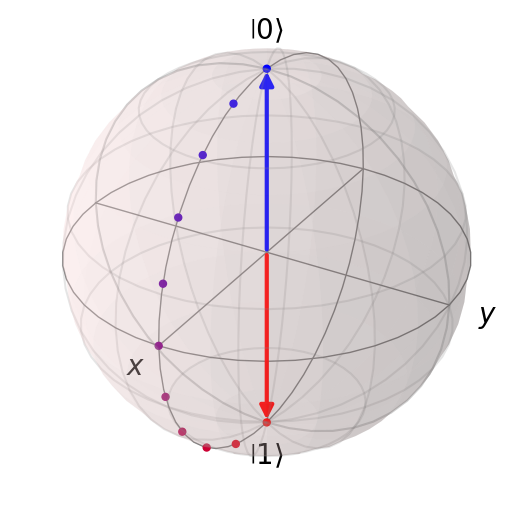

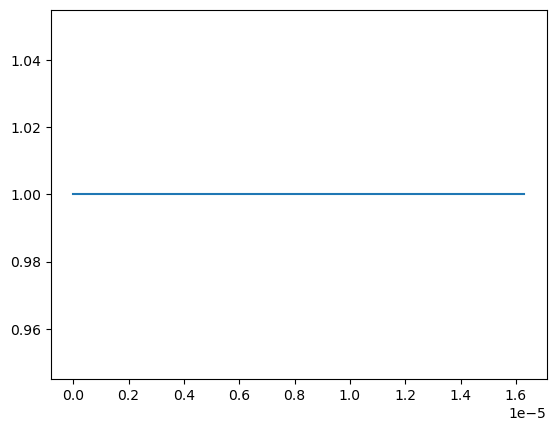

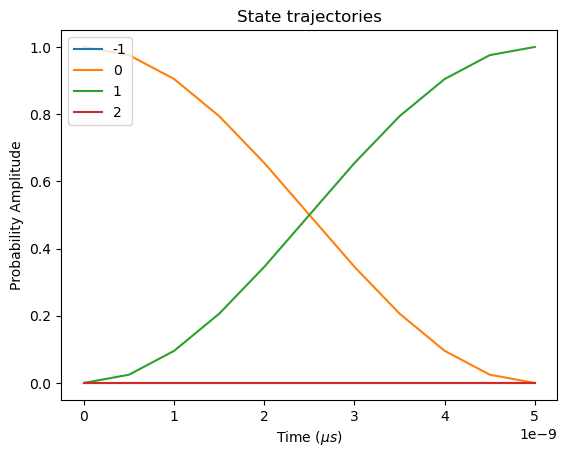

In [33]:
p_min = -1
p_max = 2
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*100
rabi_time = 2*pi/rabi_freq

time_steps = 10
durations = np.linspace(0e-6, pi/(2*dR), 1000)
atom_phases = np.zeros(len(durations))

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[1] = 1
# initial_state[2] = 1
initial_state = initial_state/ np.linalg.norm(initial_state)



for i in range(len(durations)):
    mom_dependent_free_evolution = PulseSequence()

    freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=durations[i])
    up_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, pi/2), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
    down_pulse = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, -pi/2), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
    mom_dependent_free_evolution.add_pulses([up_pulse])


    wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

    # probs = np.abs(wave_func)**2

    # fig, ax = plt.subplots()

    atom_phases[i] = (np.angle(wave_func[-1,2]) - np.angle(wave_func[-1,1])) % (2*np.pi)

plt.plot(durations, atom_phases/pi)


# plot_state_trajectories(ax=ax, wavefunc=probs, time_array=times, basis=basis)
fig, ax = plt.subplots()

# atom_phases[i] = (np.angle(wave_func[-1,3]) - np.angle(wave_func[-1,2])) % (2*np.pi)

# plt.plot(durations, atom_phases/pi)
# plt.ylim(0,2)

plot_state_trajectories(ax=ax, wavefunc=np.abs(wave_func)**2, time_array=times, basis=basis)
plot_bloch(wave_func=wave_func[:,1:3])
# plt.show()



1e-08
6.519972796370082e-05
[0.707+0.j 0.707+0.j]
[ 0.5  +0.5j   -0.501+0.499j]


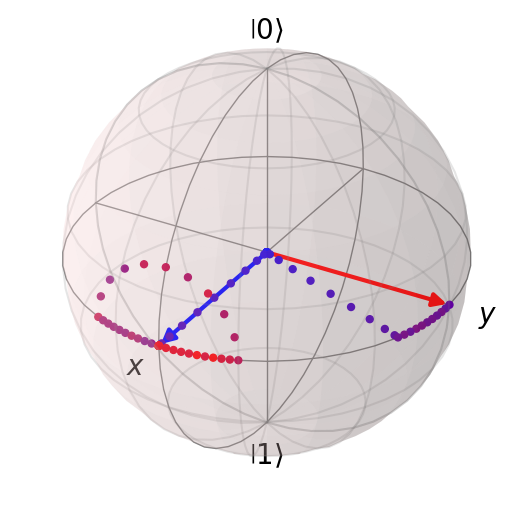

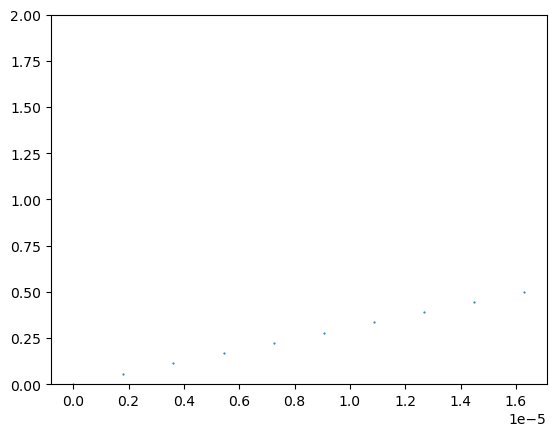

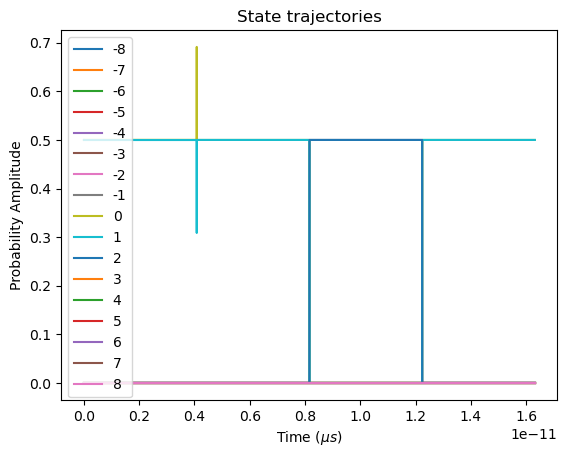

In [9]:
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*100000000
rabi_time = 2*pi/rabi_freq

time_steps = 10
durations = np.linspace(0, pi/(2*dR), 10)
atom_phases = np.zeros(len(durations))

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[8] = 1
initial_state[9] = 1
initial_state = initial_state/ np.linalg.norm(initial_state)

print(rabi_time)
print(2*pi/dR)

for i in range(len(durations)):
    mom_dependent_free_evolution = PulseSequence()


    up_pulse = UpPulse(laser_det=np.full(time_steps, 0), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
    down_pulse = DownPulse(laser_det=np.full(time_steps, 0), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
    freevolve = FreeEvolution(laser_det=np.full(time_steps, 0), duration=durations[i]/4)
    freevolve2 = FreeEvolution(laser_det=np.full(time_steps, 0), duration=durations[i]/4)

    mom_dependent_free_evolution.add_pulses([up_pulse, freevolve2, up_pulse, freevolve2, down_pulse, freevolve2, down_pulse, freevolve2])
    # mom_dependent_free_evolution.add_pulses([freevolve2, up_pulse, freevolve2, up_pulse, freevolve2, down_pulse, freevolve2, down_pulse])



    wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

    # probs = np.abs(wave_func)**2

    # fig, ax = plt.subplots()

    # atom_phases[i] = (np.angle(wave_func[-1,3]) - np.angle(wave_func[-1,2])) % (2*np.pi)
    
    atom_phases[i] = (np.angle(wave_func[-1,9]) - np.angle(wave_func[-1,8])) % (2*np.pi)

print(np.round(initial_state[8:10], 3))
print(np.round(wave_func[-1,8:10], 3))


plt.scatter(durations, atom_phases/pi, s=0.3)
plt.ylim(0,2)
# plt.xlim(0,4*2*pi/dR)


fig, ax = plt.subplots()

# atom_phases[i] = (np.angle(wave_func[-1,3]) - np.angle(wave_func[-1,2])) % (2*np.pi)

# plt.plot(durations, atom_phases/pi)
# plt.ylim(0,2)

plot_state_trajectories(ax=ax, wavefunc=np.abs(wave_func)**2, time_array=times, basis=basis)
plot_bloch(wave_func=wave_func[:,8:10]*-1)
# plot_state_trajectories(ax=ax, wavefunc=probs, time_array=times, basis=basis)



# plt.show()



### State trajectories of MDFE

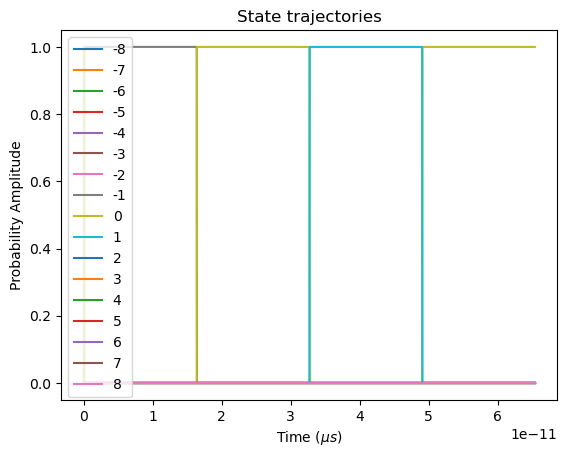

In [19]:
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*10000000
rabi_time = 2*pi/rabi_freq

time_steps = 20
duration = 2*pi/dR
atom_phases = np.zeros(len(durations))

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[8] = 1
initial_state[9] = 0
initial_state = initial_state/ np.linalg.norm(initial_state)


mom_dependent_free_evolution = PulseSequence()

up_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
down_pulse = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
freevolve = FreeEvolution(laser_det=np.full(time_steps, dR), duration=duration/4)

mom_dependent_free_evolution.add_pulses([down_pulse, freevolve, down_pulse, freevolve, up_pulse, freevolve, up_pulse, freevolve])


wave_func, times = simulate_pulses_single_atom(pulse_seq= mom_dependent_free_evolution, basis= basis, initial_state= initial_state, d_shift= 0)

probs = np.abs(wave_func)**2


fig, ax = plt.subplots()

# atom_phases[i] = (np.angle(wave_func[-1,3]) - np.angle(wave_func[-1,2])) % (2*np.pi)

# plt.plot(durations, atom_phases/pi)
# plt.ylim(0,2)

plot_state_trajectories(ax=ax, wavefunc=probs, time_array=times, basis=basis)

# plt.show()



### Verifying freevolution phase accumulation with a ramsey sequence

1e-07
(1000,)


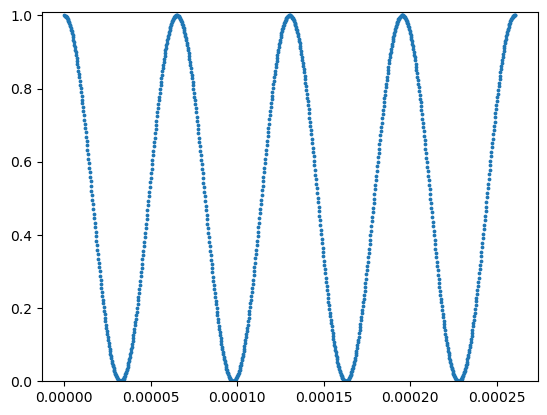

In [15]:
### MDFE

p_min = -2
p_max = 2
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*10000000
rabi_time = 2*pi/rabi_freq

time_steps = 1
durations = np.linspace(0, 4*2*pi/dR, 1000)
atom_phases = np.zeros(len(durations))

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[3] = 1
# initial_state[2] = 0
initial_state = initial_state/ np.linalg.norm(initial_state)

print(rabi_time)

for i in range(len(durations)):
    mom_dependent_free_evolution = PulseSequence()


    up_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
    up_pulse2 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4)
    down_pulse = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)
    
    freevolve = FreeEvolution(laser_det=np.full(time_steps, dR), duration=durations[i]/4)

    mom_dependent_free_evolution.add_pulses([down_pulse, freevolve, down_pulse, freevolve, up_pulse, freevolve, up_pulse, freevolve])

    pulseseq = PulseSequence()
    pulseseq.add_pulses([up_pulse2, mom_dependent_free_evolution, up_pulse2])


    wave_func, times = simulate_pulses_single_atom(pulse_seq= pulseseq, basis= basis, initial_state= initial_state, d_shift= 0)

    # probs = np.abs(wave_func)**2

    # fig, ax = plt.subplots()

    # atom_phases[i] = (np.angle(wave_func[-1,3]) - np.angle(wave_func[-1,2])) % (2*np.pi)
    
    probs = np.abs(wave_func)**2
    atom_phases[i] = probs[-1,2]

plt.scatter(durations, atom_phases, s = 3)
plt.ylim(0,1.01)

print(atom_phases.shape)



# plot_state_trajectories(ax=ax, wavefunc=probs, time_array=times, basis=basis)

# plt.show()
 


1.0
1e-08
(1000,)


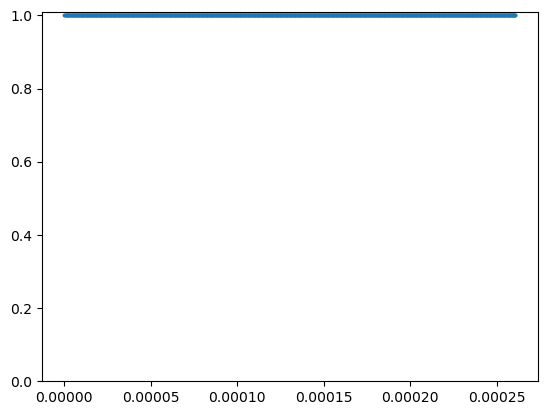

In [ ]:
### normal freevolve

p_min = -1
p_max = 2
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*100000000
rabi_time = 2*pi/rabi_freq

print(rabi_freq*rabi_time/(2*pi))

time_steps = 1
durations = np.linspace(0, 4*2*pi/dR, 1000)
atom_phases = np.zeros(len(durations))

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[1] = 1
initial_state[2] = 0
initial_state = initial_state/ np.linalg.norm(initial_state)

print(rabi_time)

for i in range(len(durations)):
    mom_dependent_free_evolution = PulseSequence()

    up_pulse2 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4)

    freevolve = FreeEvolution(laser_det=np.full(time_steps, dR), duration=durations[i])

    pulseseq = PulseSequence()
    pulseseq.add_pulses([up_pulse2, freevolve, up_pulse2])


    wave_func, times = simulate_pulses_single_atom(pulse_seq= pulseseq, basis= basis, initial_state= initial_state, d_shift= 0)

    # probs = np.abs(wave_func)**2

    # fig, ax = plt.subplots()

    # atom_phases[i] = (np.angle(wave_func[-1,3]) - np.angle(wave_func[-1,2])) % (2*np.pi)
    
    probs = np.abs(wave_func)**2
    atom_phases[i] = probs[-1,2]

plt.scatter(durations, atom_phases, s = 3)
plt.ylim(0,1.01)

print(atom_phases.shape)



# plot_state_trajectories(ax=ax, wavefunc=probs, time_array=times, basis=basis)

# plt.show()



In [124]:
print(hbar*(k_eff**2)/m/2)
print(1/dR)

96368.27489031358
1.0376858993669862e-05
